In [1]:
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import simpson
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, zoomed_inset_axes, mark_inset
from sklearn.linear_model import LinearRegression
from cycler import cycler
from scipy.interpolate import interp1d
from scipy.optimize import brentq

In [2]:
mpl.rcParams.keys()

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': 'line',
          'axes.edgecolor': 'black',
          'axes.facecolor': 'white',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': False,
          'axes.grid.axis': 'b

In [3]:
#default_cycler = (cycler(color=['k', '0.7', '0.3'])*cycler(linestyle =['-', '--', ':', '-.']))
#default_cycler = (cycler(color=['#8dd3c7', '#ffffb3', '#bebada', '#fb8072', '#80b1d3', '#fdb462', '#b3de69']))
#default_cycler = (cycler(color=['#66c2a5','#fc8d62','#8da0cb','#e78ac3','#a6d854','#ffd92f','#e5c494']))
#default_cycler = cycler(color=['#e41a1c','#377eb8','#4daf4a','#984ea3','#ff7f00','#ffff33','#a65628'])
#default_cycler = cycler(color=['#7fc97f','#beaed4','#fdc086','#ffff99','#386cb0','#f0027f','#bf5b17'])
#default_cycler = (cycler(color=['#CEB888', '#782F40','#377eb8','#4daf4a','#984ea3', '#fc8d62', '#8dd3c7']))
#plt.rc('axes', prop_cycle=default_cycler)

In [4]:
# mpl.rcParams.update(mpl.rcParamsDefault)

In [5]:
params = {
    'axes.linewidth': 1,
    'axes.facecolor': (1,1,0.8,0.4),
    'axes.labelsize': 12,
    'axes.labelcolor': '#2C2A29',
    'axes.edgecolor': '#2C2A29',
    'lines.linewidth': 2,
    'font.size': 12,
    'legend.fontsize': 12,
    'legend.facecolor': '#f7f7f7',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'text.usetex': True,
    'figure.figsize': [6,4],
    'font.serif': 'cmr10',
    'legend.shadow': True, 
    'xtick.major.size': 6,
    'ytick.major.size': 6, 
    'xtick.minor.size': 3,  
    'ytick.minor.size': 3,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
    'xtick.minor.width': 1,
    'ytick.minor.width': 1,
    'ytick.minor.visible': True,
    'xtick.minor.visible': True,
    'lines.markeredgewidth': 1,
    'savefig.dpi': 600,
    'ytick.right': True,
    'xtick.top':True,
    'ytick.direction': 'in',
    'xtick.direction': 'in',
    'errorbar.capsize': 4,
    'mathtext.fontset': 'cm',
    'mathtext.rm': 'cmr10'
   }
mpl.rcParams.update(params)
mpl.rc('font', family = 'serif', serif = 'cmr10')
mpl.rcParams['mathtext.fontset'] = 'cm'

In [6]:
default_cycler = (cycler(color=['#CEB888', '#782F40','#377eb8','#4daf4a','#984ea3', '#fc8d62', '#8dd3c7']))
plt.rc('axes', prop_cycle=default_cycler)

In [7]:
%matplotlib inline

# Single Nucleon Form Factors

In [8]:
gef=np.loadtxt('../data/GPN.txt')
#gef[:,0] /= 197.326
gwf=np.loadtxt('../data/GwPN.txt')

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1685441331.py:4: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax1 = fig.add_subplot(1,2,1)
/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1685441331.py:24: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  axins1 = inset_axes(ax1, '50%', '30%', 7)
/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1685441331.py:31: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax2 = fig.add_subplot(1,2,2)
/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1685441331.py:52: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  axins2 = inset_axes(ax2, '50%', '30%', 7)


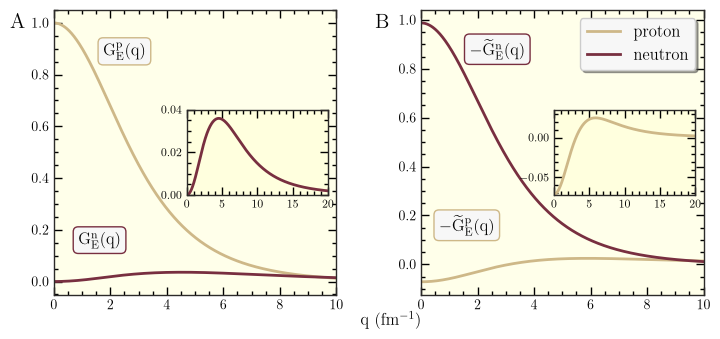

In [9]:
fig = plt.figure(figsize=(7.3,3.2))
fig.subplots_adjust(left=0.08, bottom=0.08, right=0.97, top=0.97, wspace=0.3)

ax1 = fig.add_subplot(1,2,1)
ax1.plot(gef[:,0], gef[:,1])
ax1.plot(gef[:,0], gef[:,2])
ax1.text(2.5, 0.89, r'$\mathrm{G_E^p(q)}$', size=12,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec='#CEB888',
                   fc='#f7f7f7'
                   )
         )
ax1.text(1.62, 0.16, r'$\mathrm{G_E^n(q)}$', size=12,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec='#782F40',
                   fc='#f7f7f7'
                   )
         )
ax1.set_xlim(0,10)
ax1.minorticks_on()

axins1 = inset_axes(ax1, '50%', '30%', 7)
axins1.plot(gef[:,0], gef[:,2], color='#782F40')
axins1.set_xlim(0,20)
axins1.set_ylim(0, 0.04)
axins1.tick_params(labelsize=8)
axins1.minorticks_on()

ax2 = fig.add_subplot(1,2,2)
ax2.plot(gwf[:,0], -gwf[:,1], label='proton')
ax2.plot(gwf[:,0], -gwf[:,2], label='neutron')
ax2.text(2.7, 0.88, r'$-\mathrm{\widetilde{G}_E^n(q)}$', size=12,
         ha="center", va="center",
         bbox=dict(boxstyle="round",
                   ec='#782F40',
                   fc='#f7f7f7'
                   )
         )
ax2.text(1.62, 0.16, r'$-\mathrm{\widetilde{G}_E^p(q)}$', size=12,
         va='center', ha='center',
         bbox=dict(boxstyle="round",
                   ec='#CEB888',
                   fc='#f7f7f7'
                   )
         )
ax2.set_xlim(0,10)
ax2.minorticks_on()
ax2.legend(fancybox=True, shadow=True, loc=1)

axins2 = inset_axes(ax2, '50%', '30%', 7)
axins2.plot(gwf[:,0], -gwf[:,1], color='#CEB888')
axins2.set_xlim(0,20)
axins2.set_ylim(-.072, 0.035)
axins2.tick_params(labelsize=8)
axins2.minorticks_on()

fig.text(0.02, 0.93, "A", size=15, weight="bold", horizontalalignment='left', verticalalignment='center')
fig.text(0.52, 0.93, "B", size=15, weight="bold", horizontalalignment='left', verticalalignment='center')
fig.text(0.5, 0, r'$\mathrm{q\ (fm^{-1})}$', va='center', size=12)

plt.savefig('../figures/singleNucleonff.pdf', bbox_inches='tight')

# Nuclear Density

In [10]:
pnargold=np.loadtxt('../results/densities/Ar40_fsugold_nucleon_density.dat')
pnargarnet=np.loadtxt('../results/densities/Ar40_fsugarnet_nucleon_density.dat')
pnarr022=np.loadtxt('../results/densities/Ar40_rmf022_nucleon_density.dat')
pnarr028=np.loadtxt('../results/densities/Ar40_rmf028_nucleon_density.dat')
pnarr032=np.loadtxt('../results/densities/Ar40_rmf032_nucleon_density.dat')
pnarta=np.loadtxt('../results/densities/Ar40_tamufsua_nucleon_density.dat')
pnartc=np.loadtxt('../results/densities/Ar40_tamufsuc_nucleon_density.dat')

pnigold=np.loadtxt('../results/densities/I127_fsugold_nucleon_density.dat')
pnigarnet=np.loadtxt('../results/densities/I127_fsugarnet_nucleon_density.dat')
pnir022=np.loadtxt('../results/densities/I127_rmf022_nucleon_density.dat')
pnir028=np.loadtxt('../results/densities/I127_rmf028_nucleon_density.dat')
pnir032=np.loadtxt('../results/densities/I127_rmf032_nucleon_density.dat')
pnita=np.loadtxt('../results/densities/I127_tamufsua_nucleon_density.dat')
pnitc=np.loadtxt('../results/densities/I127_tamufsuc_nucleon_density.dat')

pnxegold=np.loadtxt('../results/densities/Xe132_fsugold_nucleon_density.dat')
pnxegarnet=np.loadtxt('../results/densities/Xe132_fsugarnet_nucleon_density.dat')
pnxer022=np.loadtxt('../results/densities/Xe132_rmf022_nucleon_density.dat')
pnxer028=np.loadtxt('../results/densities/Xe132_rmf028_nucleon_density.dat')
pnxer032=np.loadtxt('../results/densities/Xe132_rmf032_nucleon_density.dat')
pnxeta=np.loadtxt('../results/densities/Xe132_tamufsua_nucleon_density.dat')
pnxetc=np.loadtxt('../results/densities/Xe132_tamufsuc_nucleon_density.dat')

pncsgold=np.loadtxt('../results/densities/Cs133_fsugold_nucleon_density.dat')
pncsgarnet=np.loadtxt('../results/densities/Cs133_fsugarnet_nucleon_density.dat')
pncsr022=np.loadtxt('../results/densities/Cs133_rmf022_nucleon_density.dat')
pncsr028=np.loadtxt('../results/densities/Cs133_rmf028_nucleon_density.dat')
pncsr032=np.loadtxt('../results/densities/Cs133_rmf032_nucleon_density.dat')
pncsta=np.loadtxt('../results/densities/Cs133_tamufsua_nucleon_density.dat')
pncstc=np.loadtxt('../results/densities/Cs133_tamufsuc_nucleon_density.dat')

rax = pnargold[:,0]

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/4206128279.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ((ax1,ax2), (ax3,ax4), (ax5, ax6), (ax7, ax8))= plt.subplots(ncols=2, nrows=4, figsize=(7.3,9.8), sharex=True,


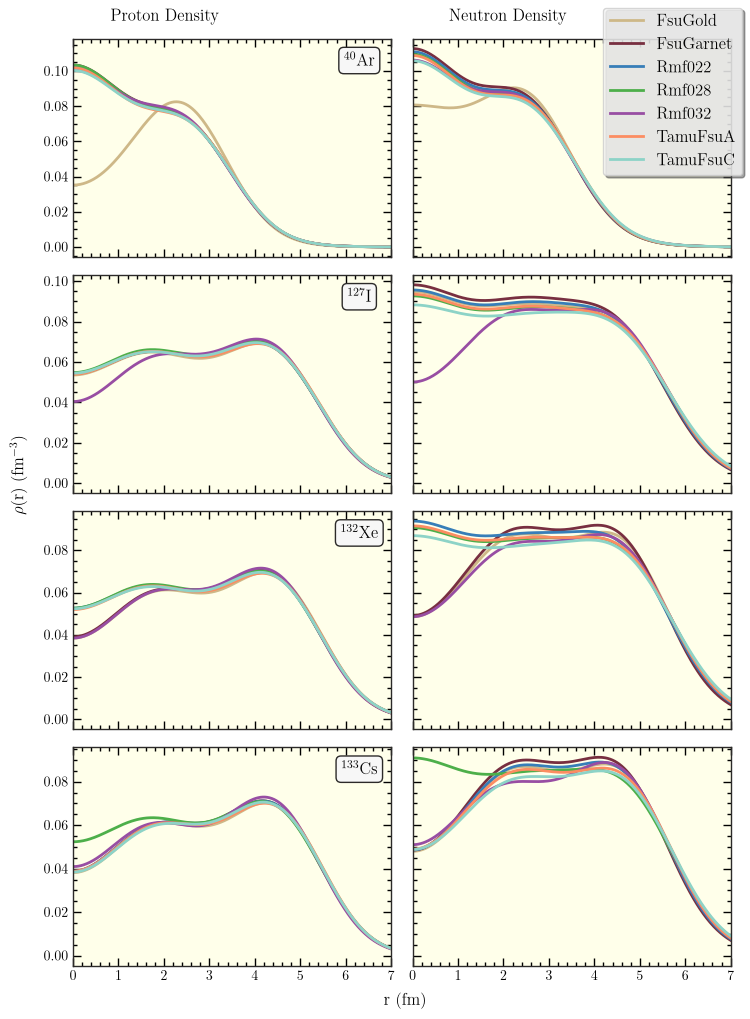

In [11]:
fig, ((ax1,ax2), (ax3,ax4), (ax5, ax6), (ax7, ax8))= plt.subplots(ncols=2, nrows=4, figsize=(7.3,9.8), sharex=True, 
                                                                  sharey='row')
fig.text(0.2, 1, 'Proton Density', ha='center')
fig.text(0.67, 1, 'Neutron Density', ha='center')
fig.text(0.5, 0, '$\mathrm{r\ (fm)}$', va='center')
fig.text(0, 0.5, r'$\mathrm{\rho (r)\ (fm^{-3})}$', rotation='vertical', ha='center')

ax1.plot(rax, pnargold[:,4], label='FsuGold')
ax1.plot(rax, pnargarnet[:,4], label='FsuGarnet')
ax1.plot(rax, pnarr022[:,4], label='Rmf022')
ax1.plot(rax, pnarr028[:,4], label='Rmf028')
ax1.plot(rax, pnarr032[:,4], label='Rmf032')
ax1.plot(rax, pnarta[:,4], label='TamuFsuA')
ax1.plot(rax, pnartc[:,4], label='TamuFsuC')
ax1.text(0.9 ,0.9, r'$\mathrm{^{40}Ar}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax1.transAxes )
ax1.set_xlim(0,7)

ax2.plot(rax, pnargold[:,2])
ax2.plot(rax, pnargarnet[:,2])
ax2.plot(rax, pnarr022[:,2])
ax2.plot(rax, pnarr028[:,2])
ax2.plot(rax, pnarr032[:,2])
ax2.plot(rax, pnarta[:,2])
ax2.plot(rax, pnartc[:,2])
ax2.set_xlim(0,7)

ax3.plot(rax, pnigold[:,4])
ax3.plot(rax, pnigarnet[:,4])
ax3.plot(rax, pnir022[:,4])
ax3.plot(rax, pnir028[:,4])
ax3.plot(rax, pnir032[:,4])
ax3.plot(rax, pnita[:,4])
ax3.plot(rax, pnitc[:,4])
ax3.text(0.9, 0.9, r'$\mathrm{^{127}I}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax3.transAxes )
ax3.set_xlim(0,7)

ax4.plot(rax, pnigold[:,2])
ax4.plot(rax, pnigarnet[:,2])
ax4.plot(rax, pnir022[:,2])
ax4.plot(rax, pnir028[:,2])
ax4.plot(rax, pnir032[:,2])
ax4.plot(rax, pnita[:,2])
ax4.plot(rax, pnitc[:,2])
ax4.set_xlim(0,7)

ax5.plot(rax, pnxegold[:,4])
ax5.plot(rax, pnxegarnet[:,4])
ax5.plot(rax, pnxer022[:,4])
ax5.plot(rax, pnxer028[:,4])
ax5.plot(rax, pnxer032[:,4])
ax5.plot(rax, pnxeta[:,4])
ax5.plot(rax, pnxetc[:,4])
ax5.text(0.9, 0.9, r'$\mathrm{^{132}Xe}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax5.transAxes )
ax5.set_xlim(0,7)

ax6.plot(rax, pnxegold[:,2])
ax6.plot(rax, pnxegarnet[:,2])
ax6.plot(rax, pnxer022[:,2])
ax6.plot(rax, pnxer028[:,2])
ax6.plot(rax, pnxer032[:,2])
ax6.plot(rax, pnxeta[:,2])
ax6.plot(rax, pnxetc[:,2])
ax6.set_xlim(0,7)

ax7.plot(rax, pncsgold[:,4])
ax7.plot(rax, pncsgarnet[:,4])
ax7.plot(rax, pncsr022[:,4])
ax7.plot(rax, pncsr028[:,4])
ax7.plot(rax, pncsr032[:,4])
ax7.plot(rax, pncsta[:,4])
ax7.plot(rax, pncstc[:,4])
ax7.text(0.9, 0.9, r'$\mathrm{^{133}Cs}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax7.transAxes )
ax7.set_xlim(0,7)

ax8.plot(rax, pncsgold[:,2])
ax8.plot(rax, pncsgarnet[:,2])
ax8.plot(rax, pncsr022[:,2])
ax8.plot(rax, pncsr028[:,2])
ax8.plot(rax, pncsr032[:,2])
ax8.plot(rax, pncsta[:,2])
ax8.plot(rax, pncstc[:,2])
ax8.set_xlim(0,7)

fig.legend()
fig.tight_layout()
fig.savefig('../figures/proton_neutron_den.pdf', bbox_inches='tight')

plt.show()

# Charge and Weak Density

In [12]:
argold=np.loadtxt('../results/densities/Ar40_fsugold_charge_densities.dat')
argarnet=np.loadtxt('../results/densities/Ar40_fsugarnet_charge_densities.dat')
arr022=np.loadtxt('../results/densities/Ar40_rmf022_charge_densities.dat')
arr028=np.loadtxt('../results/densities/Ar40_rmf028_charge_densities.dat')
arr032=np.loadtxt('../results/densities/Ar40_rmf032_charge_densities.dat')
arta=np.loadtxt('../results/densities/Ar40_tamufsua_charge_densities.dat')
artc=np.loadtxt('../results/densities/Ar40_tamufsuc_charge_densities.dat')

igold=np.loadtxt('../results/densities/I127_fsugold_charge_densities.dat')
igarnet=np.loadtxt('../results/densities/I127_fsugarnet_charge_densities.dat')
ir022=np.loadtxt('../results/densities/I127_rmf022_charge_densities.dat')
ir028=np.loadtxt('../results/densities/I127_rmf028_charge_densities.dat')
ir032=np.loadtxt('../results/densities/I127_rmf032_charge_densities.dat')
ita=np.loadtxt('../results/densities/I127_tamufsua_charge_densities.dat')
itc=np.loadtxt('../results/densities/I127_tamufsuc_charge_densities.dat')

xegold=np.loadtxt('../results/densities/Xe132_fsugold_charge_densities.dat')
xegarnet=np.loadtxt('../results/densities/Xe132_fsugarnet_charge_densities.dat')
xer022=np.loadtxt('../results/densities/Xe132_rmf022_charge_densities.dat')
xer028=np.loadtxt('../results/densities/Xe132_rmf028_charge_densities.dat')
xer032=np.loadtxt('../results/densities/Xe132_rmf032_charge_densities.dat')
xeta=np.loadtxt('../results/densities/Xe132_tamufsua_charge_densities.dat')
xetc=np.loadtxt('../results/densities/Xe132_tamufsuc_charge_densities.dat')

csgold=np.loadtxt('../results/densities/Cs133_fsugold_charge_densities.dat')
csgarnet=np.loadtxt('../results/densities/Cs133_fsugarnet_charge_densities.dat')
csr022=np.loadtxt('../results/densities/Cs133_rmf022_charge_densities.dat')
csr028=np.loadtxt('../results/densities/Cs133_rmf028_charge_densities.dat')
csr032=np.loadtxt('../results/densities/Cs133_rmf032_charge_densities.dat')
csta=np.loadtxt('../results/densities/Cs133_tamufsua_charge_densities.dat')
cstc=np.loadtxt('../results/densities/Cs133_tamufsuc_charge_densities.dat')

rax1 = argold[:,0]

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/4155630190.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(9,9.8), sharex=True, sharey='row')


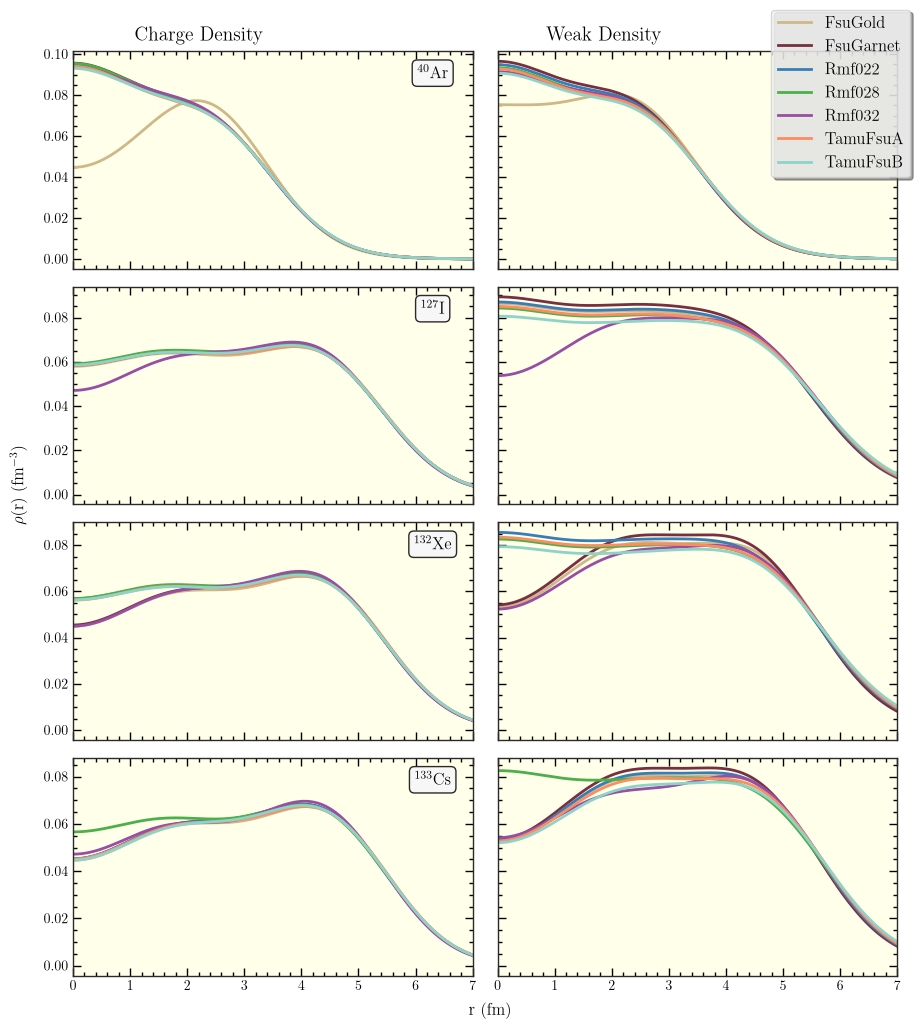

In [13]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(9,9.8), sharex=True, sharey='row')
plt.setp(ax, xlim=(0,7))

ax[0,0].plot(rax1, argold[:,1], label='FsuGold')
ax[0,0].plot(rax1, argarnet[:,1], label='FsuGarnet')
ax[0,0].plot(rax1, arr022[:,1], label='Rmf022')
ax[0,0].plot(rax1, arr028[:,1], label='Rmf028')
ax[0,0].plot(rax1, arr032[:,1], label='Rmf032')
ax[0,0].plot(rax1, arta[:,1], label='TamuFsuA')
ax[0,0].plot(rax1, artc[:,1], label='TamuFsuB')
ax[0,0].text(0.9, 0.9, r'$\mathrm{^{40}Ar}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[0,0].transAxes )

ax[0,1].plot(rax1, -argold[:,2])
ax[0,1].plot(rax1, -argarnet[:,2])
ax[0,1].plot(rax1, -arr022[:,2])
ax[0,1].plot(rax1, -arr028[:,2])
ax[0,1].plot(rax1, -arr032[:,2])
ax[0,1].plot(rax1, -arta[:,2])
ax[0,1].plot(rax1, -artc[:,2])

ax[1,0].plot(rax1, igold[:,1])
ax[1,0].plot(rax1, igarnet[:,1])
ax[1,0].plot(rax1, ir022[:,1])
ax[1,0].plot(rax1, ir028[:,1])
ax[1,0].plot(rax1, ir032[:,1])
ax[1,0].plot(rax1, ita[:,1])
ax[1,0].plot(rax1, itc[:,1])
ax[1,0].text(0.9, 0.9, r'$\mathrm{^{127}I}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[1,0].transAxes )

ax[1,1].plot(rax1, -igold[:,2])
ax[1,1].plot(rax1, -igarnet[:,2])
ax[1,1].plot(rax1, -ir022[:,2])
ax[1,1].plot(rax1, -ir028[:,2])
ax[1,1].plot(rax1, -ir032[:,2])
ax[1,1].plot(rax1, -ita[:,2])
ax[1,1].plot(rax1, -itc[:,2])

ax[2,0].plot(rax1, xegold[:,1])
ax[2,0].plot(rax1, xegarnet[:,1])
ax[2,0].plot(rax1, xer022[:,1])
ax[2,0].plot(rax1, xer028[:,1])
ax[2,0].plot(rax1, xer032[:,1])
ax[2,0].plot(rax1, xeta[:,1])
ax[2,0].plot(rax1, xetc[:,1])
ax[2,0].text(0.9, 0.9, r'$\mathrm{^{132}Xe}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[2,0].transAxes )

ax[2,1].plot(rax1, -xegold[:,2])
ax[2,1].plot(rax1, -xegarnet[:,2])
ax[2,1].plot(rax1, -xer022[:,2])
ax[2,1].plot(rax1, -xer028[:,2])
ax[2,1].plot(rax1, -xer032[:,2])
ax[2,1].plot(rax1, -xeta[:,2])
ax[2,1].plot(rax1, -xetc[:,2])

ax[3,0].plot(rax1, csgold[:,1])
ax[3,0].plot(rax1, csgarnet[:,1])
ax[3,0].plot(rax1, csr022[:,1])
ax[3,0].plot(rax1, csr028[:,1])
ax[3,0].plot(rax1, csr032[:,1])
ax[3,0].plot(rax1, csta[:,1])
ax[3,0].plot(rax1, cstc[:,1])
ax[3,0].text(0.9, 0.9, r'$\mathrm{^{133}Cs}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[3,0].transAxes )

ax[3,1].plot(rax1, -csgold[:,2])
ax[3,1].plot(rax1, -csgarnet[:,2])
ax[3,1].plot(rax1, -csr022[:,2])
ax[3,1].plot(rax1, -csr028[:,2])
ax[3,1].plot(rax1, -csr032[:,2])
ax[3,1].plot(rax1, -csta[:,2])
ax[3,1].plot(rax1, -cstc[:,2])

fig.text(0.2, 0.99, 'Charge Density', ha='center', size=14)
fig.text(0.65, 0.99, 'Weak Density', ha='center', size=14)
fig.text(0.5, 0, '$\mathrm{r\ (fm)}$', va='center', size=12)
fig.text(0, 0.5, r'$\mathrm{\rho (r)\ (fm^{-3})}$', rotation='vertical', ha='center', size=12)
fig.legend(loc=1, bbox_to_anchor=(1.,1.03))
fig.tight_layout()
fig.savefig('../figures/nuclearden.pdf', bbox_inches='tight')

# Compare Charge and Point Density 

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/951822901.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(9.5,5.5), sharex=True, sharey='row')


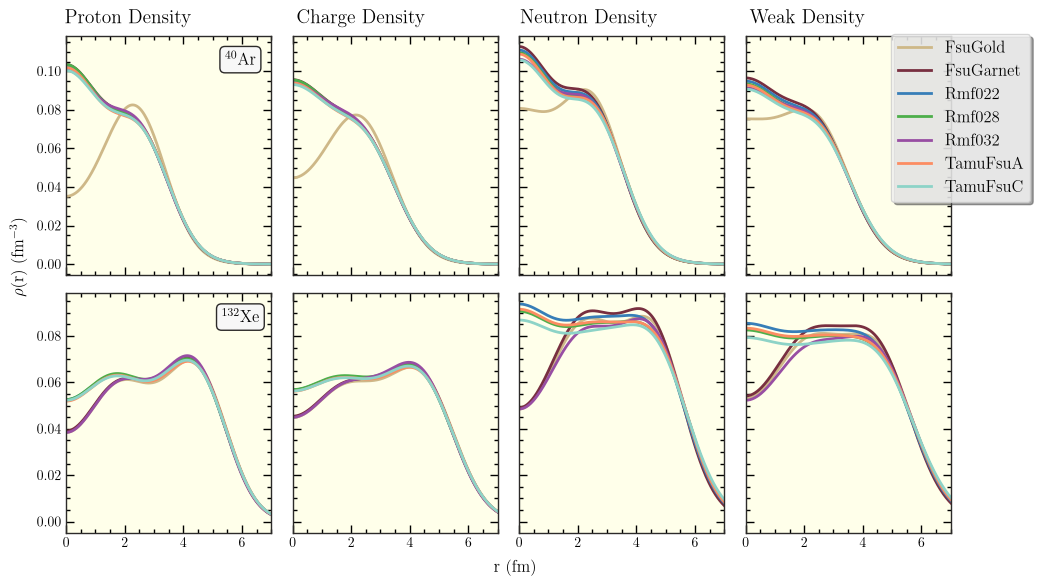

In [14]:
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(9.5,5.5), sharex=True, sharey='row')
plt.setp(ax, xlim=(0,7))
plt.subplots_adjust(wspace=0, hspace=0)

ax[0,0].plot(rax, pnargold[:,4], label='FsuGold')
ax[0,0].plot(rax, pnargarnet[:,4], label='FsuGarnet')
ax[0,0].plot(rax, pnarr022[:,4], label='Rmf022')
ax[0,0].plot(rax, pnarr028[:,4], label='Rmf028')
ax[0,0].plot(rax, pnarr032[:,4], label='Rmf032')
ax[0,0].plot(rax, pnarta[:,4], label='TamuFsuA')
ax[0,0].plot(rax, pnartc[:,4], label='TamuFsuC')
ax[0,0].text(0.85 ,0.9, r'$\mathrm{^{40}Ar}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[0,0].transAxes )

ax[0,1].plot(rax1, argold[:,1])
ax[0,1].plot(rax1, argarnet[:,1])
ax[0,1].plot(rax1, arr022[:,1])
ax[0,1].plot(rax1, arr028[:,1])
ax[0,1].plot(rax1, arr032[:,1])
ax[0,1].plot(rax1, arta[:,1])
ax[0,1].plot(rax1, artc[:,1])

ax[0,2].plot(rax, pnargold[:,2])
ax[0,2].plot(rax, pnargarnet[:,2])
ax[0,2].plot(rax, pnarr022[:,2])
ax[0,2].plot(rax, pnarr028[:,2])
ax[0,2].plot(rax, pnarr032[:,2])
ax[0,2].plot(rax, pnarta[:,2])
ax[0,2].plot(rax, pnartc[:,2])

ax[0,3].plot(rax1, -argold[:,2])
ax[0,3].plot(rax1, -argarnet[:,2])
ax[0,3].plot(rax1, -arr022[:,2])
ax[0,3].plot(rax1, -arr028[:,2])
ax[0,3].plot(rax1, -arr032[:,2])
ax[0,3].plot(rax1, -arta[:,2])
ax[0,3].plot(rax1, -artc[:,2])


ax[1,0].plot(rax, pnxegold[:,4])
ax[1,0].plot(rax, pnxegarnet[:,4])
ax[1,0].plot(rax, pnxer022[:,4])
ax[1,0].plot(rax, pnxer028[:,4])
ax[1,0].plot(rax, pnxer032[:,4])
ax[1,0].plot(rax, pnxeta[:,4])
ax[1,0].plot(rax, pnxetc[:,4])
ax[1,0].text(0.85, 0.9, r'$\mathrm{^{132}Xe}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[1,0].transAxes )

ax[1,1].plot(rax1, xegold[:,1])
ax[1,1].plot(rax1, xegarnet[:,1])
ax[1,1].plot(rax1, xer022[:,1])
ax[1,1].plot(rax1, xer028[:,1])
ax[1,1].plot(rax1, xer032[:,1])
ax[1,1].plot(rax1, xeta[:,1])
ax[1,1].plot(rax1, xetc[:,1])

ax[1,2].plot(rax, pnxegold[:,2])
ax[1,2].plot(rax, pnxegarnet[:,2])
ax[1,2].plot(rax, pnxer022[:,2])
ax[1,2].plot(rax, pnxer028[:,2])
ax[1,2].plot(rax, pnxer032[:,2])
ax[1,2].plot(rax, pnxeta[:,2])
ax[1,2].plot(rax, pnxetc[:,2])

ax[1,3].plot(rax1, -xegold[:,2])
ax[1,3].plot(rax1, -xegarnet[:,2])
ax[1,3].plot(rax1, -xer022[:,2])
ax[1,3].plot(rax1, -xer028[:,2])
ax[1,3].plot(rax1, -xer032[:,2])
ax[1,3].plot(rax1, -xeta[:,2])
ax[1,3].plot(rax1, -xetc[:,2])

fig.text(0.115, 0.99, 'Proton Density', ha='center', size=14)
fig.text(0.36, 0.99, 'Charge Density', ha='center', size=14)
fig.text(0.6, 0.99, 'Neutron Density', ha='center', size=14)
fig.text(0.83, 0.99, 'Weak Density', ha='center', size=14)
fig.text(0.5, 0, '$\mathrm{r\ (fm)}$', va='center', size=12)
fig.text(0, 0.5, r'$\mathrm{\rho (r)\ (fm^{-3})}$', rotation='vertical', ha='center', size=12)
fig.legend(loc=3, bbox_to_anchor=(.91,.65))

fig.tight_layout()
fig.savefig('../figures/dencomp.pdf', bbox_inches='tight')

# Neutron and Weak Radius Correlation

In [15]:
import re

def skin_by_model(path):
    text = open(path).read()
    entries = re.findall(r'#{1,3}\s*(\S+)\s*\n\s*([\d.\- ]+)', text)
    return {name.lower(): [float(v) for v in row.split()] for name, row in entries}

SKIN_MODEL_ORDER = ['fsugold', 'fsugarnet', 'rmf022', 'rmf028', 'rmf032', 'tamufsua', 'tamufsuc']

def skin_series(nucleus, col):
    table = skin_by_model(f'../results/skins/{nucleus}_neutron_skins.txt')
    return np.array([table[m][col] for m in SKIN_MODEL_ORDER])

pbskins = skin_series('Pb208', 2)
xeskins = skin_series('Xe132', 2)
csskins = skin_series('Cs133', 2)
iskins = skin_series('I127', 2)
arskins = skin_series('Ar40', 2)
print(pbskins)
print(arskins)

[0.2043  0.15931 0.21387 0.28163 0.31623 0.247   0.32675]
[0.11067 0.0807  0.09707 0.11561 0.12691 0.1058  0.13184]


In [16]:
arfit = np.polyfit(pbskins, arskins, 1)
arfitfn = np.poly1d(arfit)
ifit = np.polyfit(pbskins, iskins, 1)
ifitfn = np.poly1d(ifit)
xefit = np.polyfit(pbskins, xeskins, 1)
xefitfn = np.poly1d(xefit)
csfit = np.polyfit(pbskins, csskins, 1)
csfitfn = np.poly1d(csfit)
print(arfit)

[0.26543674 0.04347532]


In [17]:
x = pbskins.reshape((-1,1))
armodel = LinearRegression().fit(x, arskins)
imodel = LinearRegression().fit(x, iskins)
xemodel = LinearRegression().fit(x, xeskins)
csmodel = LinearRegression().fit(x, csskins)
print(armodel.score(x, arskins))

0.8780721927074291


/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/3216931111.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax1, ax2, ax3, ax4) =  plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(5,7))


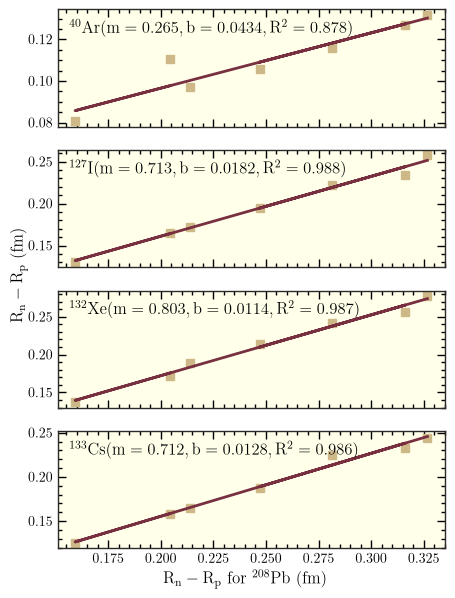

In [18]:
fig, (ax1, ax2, ax3, ax4) =  plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(5,7))
ax1.plot(pbskins, arskins,'s', pbskins, arfitfn(pbskins))
ax1.text(0.03, 0.8, '$\mathrm{^{40}Ar(m=0.265, b=0.0434, R^2=0.878)}$', transform=ax1.transAxes)

ax2.plot(pbskins, iskins, 's', pbskins, ifitfn(pbskins))
ax2.text(0.03, 0.8, '$\mathrm{^{127}I(m=0.713, b=0.0182, R^2=0.988)}$', transform=ax2.transAxes)

ax3.plot(pbskins, xeskins, 's', pbskins, xefitfn(pbskins))
ax3.text(0.03, 0.8, '$\mathrm{^{132}Xe(m=0.803, b=0.0114, R^2=0.987)}$', transform=ax3.transAxes)

ax4.plot(pbskins, csskins, 's', pbskins, csfitfn(pbskins))
ax4.text(0.03, 0.8, '$\mathrm{^{133}Cs(m=0.712, b=0.0128, R^2=0.986)}$',transform=ax4.transAxes)

fig.text(0.5, 0.06, r'$\mathrm{R_n-R_p\ for\ ^{208}Pb\ (fm)}$', ha='center')
fig.text(0.03, 0.5, r'$\mathrm{R_n-R_p\ (fm)}$', rotation='vertical', va='center')

fig.savefig('../figures/neutron_radius_corr.pdf', bbox_inches='tight')
plt.show()

In [19]:
pbwskins = skin_series('Pb208', 5)
xewskins = skin_series('Xe132', 5)
cswskins = skin_series('Cs133', 5)
iwskins = skin_series('I127', 5)
arwskins = skin_series('Ar40', 5)
print(pbwskins)

[0.21508 0.1684  0.22501 0.29528 0.33114 0.25937 0.34204]


In [20]:
arwfit = np.polyfit(pbwskins, arwskins, 1)
arwfitfn = np.poly1d(arwfit)
iwfit = np.polyfit(pbwskins, iwskins, 1)
iwfitfn = np.poly1d(iwfit)
xewfit = np.polyfit(pbwskins, xewskins, 1)
xewfitfn = np.poly1d(xewfit)
cswfit = np.polyfit(pbwskins, cswskins, 1)
cswfitfn = np.poly1d(cswfit)
cswfit
np.corrcoef(pbwskins,arwskins)

array([[1.        , 0.93720351],
       [0.93720351, 1.        ]])

In [21]:
arwmodel = LinearRegression().fit(x, arwskins)
iwmodel = LinearRegression().fit(x, iwskins)
xewmodel = LinearRegression().fit(x, xewskins)
cswmodel = LinearRegression().fit(x, cswskins)
print(np.sqrt(arwmodel.score(x, arwskins)))
print(cswfit)

0.9371997563637697
[0.71349697 0.01402161]


/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1366662837.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax1, ax2, ax3, ax4) =  plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(5,7))


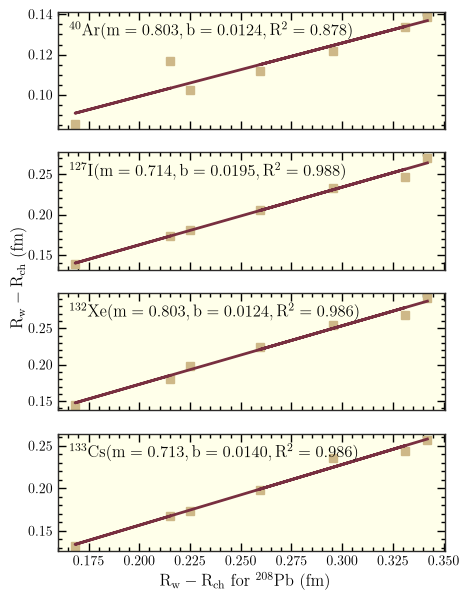

In [22]:
fig, (ax1, ax2, ax3, ax4) =  plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(5,7))
ax1.plot(pbwskins, arwskins,'s', pbwskins, arwfitfn(pbwskins))
ax1.text(0.03, 0.8, r'$\mathrm{^{40}Ar(m=0.803, b=0.0124, R^2=0.878)}$', transform=ax1.transAxes)

ax2.plot(pbwskins, iwskins, 's', pbwskins, iwfitfn(pbwskins))
ax2.text(0.03, 0.8, r'$\mathrm{^{127}I(m=0.714, b=0.0195, R^2=0.988)}$', transform=ax2.transAxes)

ax3.plot(pbwskins, xewskins, 's', pbwskins, xewfitfn(pbwskins))
ax3.text(0.03, 0.8, r'$\mathrm{^{132}Xe(m=0.803, b=0.0124, R^2=0.986)}$', transform=ax3.transAxes)

ax4.plot(pbwskins, cswskins, 's', pbwskins, cswfitfn(pbwskins))
ax4.text(0.03, 0.8, r'$\mathrm{^{133}Cs(m=0.713, b=0.0140, R^2=0.986)}$', transform=ax4.transAxes)

fig.text(0.5, 0.06, r'$\mathrm{R_w-R_{ch}\ for\ ^{208}Pb\ (fm)}$', ha='center')
fig.text(0.03, 0.5, r'$\mathrm{R_w-R_{ch}\ (fm)}$', rotation='vertical', va='center')
fig.savefig('../figures/weak_radius_corr.pdf',  bbox_inches='tight')
plt.show()

In [23]:
arcwfit = np.polyfit(arskins, arwskins, 1)
arcwfitfn = np.poly1d(arcwfit)
icwfit = np.polyfit(iskins, iwskins, 1)
icwfitfn = np.poly1d(icwfit)
xecwfit = np.polyfit(xeskins, xewskins, 1)
xecwfitfn = np.poly1d(xecwfit)
cscwfit = np.polyfit(csskins, cswskins, 1)
cscwfitfn = np.poly1d(cscwfit)
np.corrcoef(arskins, arwskins)

array([[1.        , 0.99999978],
       [0.99999978, 1.        ]])

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/862119644.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(nrows=2)


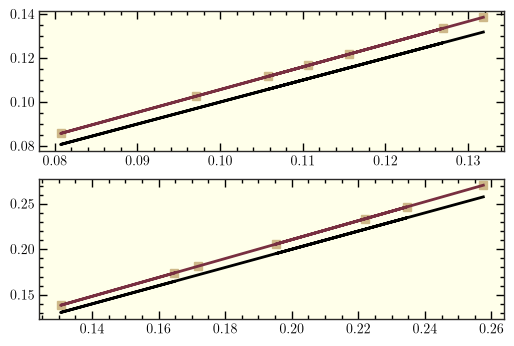

In [24]:
fig, ax = plt.subplots(nrows=2)

ax[0].plot(arskins, arwskins, 's', arskins, arcwfitfn(arskins), arskins, arskins, 'k')
ax[1].plot(iskins, iwskins, 's', iskins, icwfitfn(iskins), iskins, iskins, 'k')

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1366662837.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, (ax1, ax2, ax3, ax4) =  plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(5,7))


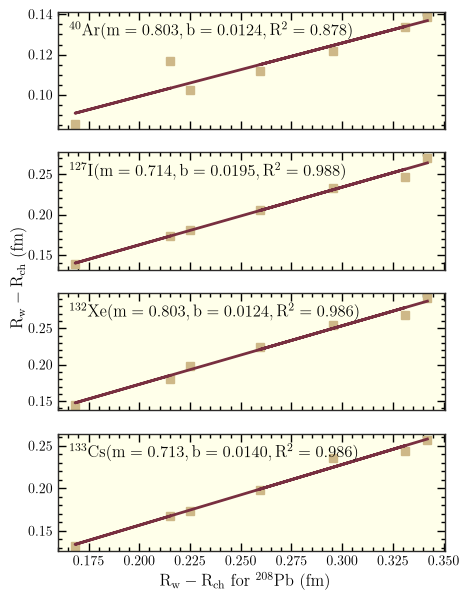

In [25]:
fig, (ax1, ax2, ax3, ax4) =  plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(5,7))
ax1.plot(pbwskins, arwskins,'s', pbwskins, arwfitfn(pbwskins))
ax1.text(0.03, 0.8, r'$\mathrm{^{40}Ar(m=0.803, b=0.0124, R^2=0.878)}$', transform=ax1.transAxes)

ax2.plot(pbwskins, iwskins, 's', pbwskins, iwfitfn(pbwskins))
ax2.text(0.03, 0.8, r'$\mathrm{^{127}I(m=0.714, b=0.0195, R^2=0.988)}$', transform=ax2.transAxes)

ax3.plot(pbwskins, xewskins, 's', pbwskins, xewfitfn(pbwskins))
ax3.text(0.03, 0.8, r'$\mathrm{^{132}Xe(m=0.803, b=0.0124, R^2=0.986)}$', transform=ax3.transAxes)

ax4.plot(pbwskins, cswskins, 's', pbwskins, cswfitfn(pbwskins))
ax4.text(0.03, 0.8, r'$\mathrm{^{133}Cs(m=0.713, b=0.0140, R^2=0.986)}$', transform=ax4.transAxes)

fig.text(0.5, 0.06, r'$\mathrm{R_w-R_{ch}\ for\ ^{208}Pb\ (fm)}$', ha='center')
fig.text(0.03, 0.5, r'$\mathrm{R_w-R_{ch}\ (fm)}$', rotation='vertical', va='center')
fig.savefig('../figures/weak_radius_corr.pdf',  bbox_inches='tight')
plt.show()

# Weak Form Factor

In [26]:
ffcsgold=np.loadtxt('../results/densities/Cs133_fsugold_WeakFF.dat')
ffcsgarnet=np.loadtxt('../results/densities/Cs133_fsugarnet_WeakFF.dat')
ffcsr022=np.loadtxt('../results/densities/Cs133_rmf022_WeakFF.dat')
ffcsr028=np.loadtxt('../results/densities/Cs133_rmf028_WeakFF.dat')
ffcsr032=np.loadtxt('../results/densities/Cs133_rmf032_WeakFF.dat')
ffcsta=np.loadtxt('../results/densities/Cs133_tamufsua_WeakFF.dat')
ffcstc=np.loadtxt('../results/densities/Cs133_tamufsuc_WeakFF.dat')

In [27]:
ffargold=np.loadtxt('../results/densities/Ar40_fsugold_WeakFF.dat')
ffargarnet=np.loadtxt('../results/densities/Ar40_fsugarnet_WeakFF.dat')
ffarr022=np.loadtxt('../results/densities/Ar40_rmf022_WeakFF.dat')
ffarr028=np.loadtxt('../results/densities/Ar40_rmf028_WeakFF.dat')
ffarr032=np.loadtxt('../results/densities/Ar40_rmf032_WeakFF.dat')
ffarta=np.loadtxt('../results/densities/Ar40_tamufsua_WeakFF.dat')
ffartc=np.loadtxt('../results/densities/Ar40_tamufsuc_WeakFF.dat')

ffigold=np.loadtxt('../results/densities/I127_fsugold_WeakFF.dat')
ffigarnet=np.loadtxt('../results/densities/I127_fsugarnet_WeakFF.dat')
ffir022=np.loadtxt('../results/densities/I127_rmf022_WeakFF.dat')
ffir028=np.loadtxt('../results/densities/I127_rmf028_WeakFF.dat')
ffir032=np.loadtxt('../results/densities/I127_rmf032_WeakFF.dat')
ffita=np.loadtxt('../results/densities/I127_tamufsua_WeakFF.dat')
ffitc=np.loadtxt('../results/densities/I127_tamufsuc_WeakFF.dat')

ffxegold=np.loadtxt('../results/densities/Xe132_fsugold_WeakFF.dat')
ffxegarnet=np.loadtxt('../results/densities/Xe132_fsugarnet_WeakFF.dat')
ffxer022=np.loadtxt('../results/densities/Xe132_rmf022_WeakFF.dat')
ffxer028=np.loadtxt('../results/densities/Xe132_rmf028_WeakFF.dat')
ffxer032=np.loadtxt('../results/densities/Xe132_rmf032_WeakFF.dat')
ffxeta=np.loadtxt('../results/densities/Xe132_tamufsua_WeakFF.dat')
ffxetc=np.loadtxt('../results/densities/Xe132_tamufsuc_WeakFF.dat')

ffcsgold=np.loadtxt('../results/densities/Cs133_fsugold_WeakFF.dat')
ffcsgarnet=np.loadtxt('../results/densities/Cs133_fsugarnet_WeakFF.dat')
ffcsr022=np.loadtxt('../results/densities/Cs133_rmf022_WeakFF.dat')
ffcsr028=np.loadtxt('../results/densities/Cs133_rmf028_WeakFF.dat')
ffcsr032=np.loadtxt('../results/densities/Cs133_rmf032_WeakFF.dat')
ffcsta=np.loadtxt('../results/densities/Cs133_tamufsua_WeakFF.dat')
ffcstc=np.loadtxt('../results/densities/Cs133_tamufsuc_WeakFF.dat')
qax = ffxegold[:,0]

In [28]:
ffcs=np.abs(ffcstc[:,2])
ffxe=np.abs(ffxetc[:,2])
ffi=np.abs(ffitc[:,2])
ffar=np.abs(ffartc[:,2])

In [29]:
index=0
for i in range(5):
    while ffcs[index]>ffcs[index+1]:
        index+=1   
    print(index,ffcstc[:,0][index], ffcstc[:,2][index])
    index+=50

76 0.7599999904632568 -0.0007170173589900831
136 1.3600000143051147 0.0006200232611335734
193 1.9299999475479126 0.0001618187679407578
265 2.6499998569488525 -1.584087645236442e-05
321 3.2100000381469727 6.403587075252818e-07


In [30]:
from scipy.interpolate import interp1d
from scipy.optimize import brentq

x = ffcstc[:,0]
y = ffcstc[:,2]
fcs = interp1d(x,y,kind='cubic')

x = ffxetc[:,0]
y = ffxetc[:,2]
fxe = interp1d(x,y,kind='cubic')

x = ffitc[:,0]
y = ffitc[:,2]
fi = interp1d(x,y,kind='cubic')

print('Cesium:')
print(brentq(fcs,0.7,0.76))
print(brentq(fcs,1.3,1.37))
print(brentq(fcs,1.9,2.1))
print(brentq(fcs,2.6,2.8))
print(brentq(fcs,3.0,3.4))

print('Xenon:')
print(brentq(fxe,0.7,0.78))
print(brentq(fxe,1.3,1.37))

print('Iodine:')
print(brentq(fi,0.76,0.78))
print(brentq(fi,1.3,1.4))

Cesium:
0.7590209224493214
1.3558927251054955
1.9341855004343784
2.653648271393848
3.211475923339723
Xenon:
0.767927432778106
1.3537203157420623
Iodine:
0.7795183212461593
1.3688674052498055


/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/4062353286.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(9,9.8), sharex=True, sharey='row')


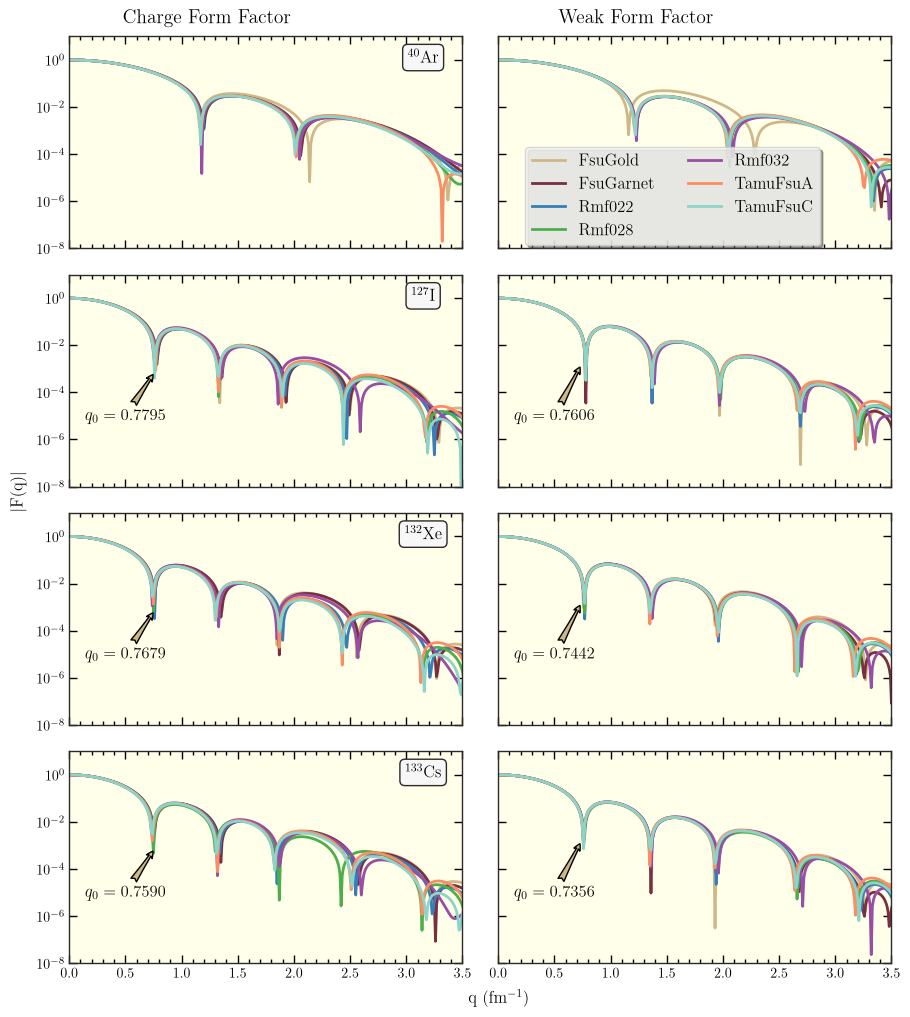

In [31]:
fig, ax = plt.subplots(nrows=4, ncols=2, figsize=(9,9.8), sharex=True, sharey='row')
plt.setp(ax, xlim=(0,3.5))
plt.setp(ax, ylim=(10**(-8),10**1))

ax[0,0].semilogy(qax, np.abs(ffargold[:,1]), label='FsuGold')
ax[0,0].semilogy(qax, np.abs(ffargarnet[:,1]), label='FsuGarnet')
ax[0,0].semilogy(qax, np.abs(ffarr022[:,1]), label='Rmf022')
ax[0,0].semilogy(qax, np.abs(ffarr028[:,1]), label='Rmf028')
ax[0,0].semilogy(qax, np.abs(ffarr032[:,1]), label='Rmf032')
ax[0,0].semilogy(qax, np.abs(ffarta[:,1]), label='TamuFsuA')
ax[0,0].semilogy(qax, np.abs(ffartc[:,1]), label='TamuFsuC')
ax[0,0].text(0.9, 0.9, r'$^{40}\mathrm{Ar}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[0,0].transAxes )

ax[0,1].semilogy(qax, np.abs(ffargold[:,2]))
ax[0,1].semilogy(qax, np.abs(ffargarnet[:,2]))
ax[0,1].semilogy(qax, np.abs(ffarr022[:,2]))
ax[0,1].semilogy(qax, np.abs(ffarr028[:,2]))
ax[0,1].semilogy(qax, np.abs(ffarr032[:,2]))
ax[0,1].semilogy(qax, np.abs(ffarta[:,2]))
ax[0,1].semilogy(qax, np.abs(ffartc[:,2]))

ax[1,0].semilogy(qax, np.abs(ffigold[:,1]))
ax[1,0].semilogy(qax, np.abs(ffigarnet[:,1]))
ax[1,0].semilogy(qax, np.abs(ffir022[:,1]))
ax[1,0].semilogy(qax, np.abs(ffir028[:,1]))
ax[1,0].semilogy(qax, np.abs(ffir032[:,1]))
ax[1,0].semilogy(qax, np.abs(ffita[:,1]))
ax[1,0].semilogy(qax, np.abs(ffitc[:,1]))
ax[1,0].text(0.9, 0.9, r'$^{127}\mathrm{I}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[1,0].transAxes )

ax[1,1].semilogy(qax, np.abs(ffigold[:,2]))
ax[1,1].semilogy(qax, np.abs(ffigarnet[:,2]))
ax[1,1].semilogy(qax, np.abs(ffir022[:,2]))
ax[1,1].semilogy(qax, np.abs(ffir028[:,2]))
ax[1,1].semilogy(qax, np.abs(ffir032[:,2]))
ax[1,1].semilogy(qax, np.abs(ffita[:,2]))
ax[1,1].semilogy(qax, np.abs(ffitc[:,2]))

ax[2,0].semilogy(qax, np.abs(ffxegold[:,1]))
ax[2,0].semilogy(qax, np.abs(ffxegarnet[:,1]))
ax[2,0].semilogy(qax, np.abs(ffxer022[:,1]))
ax[2,0].semilogy(qax, np.abs(ffxer028[:,1]))
ax[2,0].semilogy(qax, np.abs(ffxer032[:,1]))
ax[2,0].semilogy(qax, np.abs(ffxeta[:,1]))
ax[2,0].semilogy(qax, np.abs(ffxetc[:,1]))
ax[2,0].text(0.9, 0.9, r'$^{132}\mathrm{Xe}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[2,0].transAxes )

ax[2,1].semilogy(qax, np.abs(ffxegold[:,2]))
ax[2,1].semilogy(qax, np.abs(ffxegarnet[:,2]))
ax[2,1].semilogy(qax, np.abs(ffxer022[:,2]))
ax[2,1].semilogy(qax, np.abs(ffxer028[:,2]))
ax[2,1].semilogy(qax, np.abs(ffxer032[:,2]))
ax[2,1].semilogy(qax, np.abs(ffxeta[:,2]))
ax[2,1].semilogy(qax, np.abs(ffxetc[:,2]))

ax[3,0].semilogy(qax, np.abs(ffcsgold[:,1]))
ax[3,0].semilogy(qax, np.abs(ffcsgarnet[:,1]))
ax[3,0].semilogy(qax, np.abs(ffcsr022[:,1]))
ax[3,0].semilogy(qax, np.abs(ffcsr028[:,1]))
ax[3,0].semilogy(qax, np.abs(ffcsr032[:,1]))
ax[3,0].semilogy(qax, np.abs(ffcsta[:,1]))
ax[3,0].semilogy(qax, np.abs(ffcstc[:,1]))
ax[3,0].text(0.9, 0.9, r'$^{133}\mathrm{Cs}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax[3,0].transAxes)

ax[3,1].semilogy(qax, np.abs(ffcsgold[:,2]))
ax[3,1].semilogy(qax, np.abs(ffcsgarnet[:,2]))
ax[3,1].semilogy(qax, np.abs(ffcsr022[:,2]))
ax[3,1].semilogy(qax, np.abs(ffcsr028[:,2]))
ax[3,1].semilogy(qax, np.abs(ffcsr032[:,2]))
ax[3,1].semilogy(qax, np.abs(ffcsta[:,2]))
ax[3,1].semilogy(qax, np.abs(ffcstc[:,2]))
fig.tight_layout()

# ax[1,0].axvline(x=0.759, ymin=0, ymax=1, c='red', ls='--', lw=1.5, zorder=0, clip_on=False)
# ax[2,0].axvline(x=0.759, ymin=0, ymax=1.1, c='red', ls='--', lw=1.5, zorder=0, clip_on=False)
# ax[3,0].axvline(x=0.759, ymin=0, ymax=1.1, c='red', ls='--', lw=1.5, zorder=0, clip_on=False)
# ax[3,0].axvline(x=1.355, ymin=0, ymax=1.1, c='red', ls='--', lw=1.5, zorder=0, clip_on=False)

# ax[1,1].axvline(x=0.74, ymin=0, ymax=1, c='red', ls='--', lw=1, zorder=0, clip_on=False)
# ax[2,1].axvline(x=0.74 , ymin=0, ymax=1.1, c='red', ls='--', lw=1, zorder=0, clip_on=False)
# ax[3,1].axvline(x=0.74, ymin=0, ymax=1.1, c='red', ls='--', lw=1, zorder=0, clip_on=False)

ax[1,0].annotate(r'$q_0=0.7795$', xy=(0.7599,0.000717), xytext=(.5, 10**-5), va='center', ha='center', 
                arrowprops=dict(arrowstyle='fancy'), fontsize=12
                )
ax[1,1].annotate(r'$q_0=0.7606$', xy=(0.7400,0.0015), xytext=(.5, 10**-5), va='center', ha='center', 
                arrowprops=dict(arrowstyle='fancy'), fontsize=12
                )
ax[2,0].annotate(r'$q_0=0.7679$', xy=(0.7599,0.000717), xytext=(.5, 10**-5), va='center', ha='center', 
                arrowprops=dict(arrowstyle='fancy'), fontsize=12
                )
ax[2,1].annotate(r'$q_0=0.7442$', xy=(0.7400,0.0015), xytext=(.5, 10**-5), va='center', ha='center', 
                arrowprops=dict(arrowstyle='fancy'), fontsize=12
                )
ax[3,0].annotate(r'$q_0=0.7590$', xy=(0.7599,0.000717), xytext=(.5, 10**-5), va='center', ha='center', 
                arrowprops=dict(arrowstyle='fancy'), fontsize=12
                )
ax[3,1].annotate(r'$q_0=0.7356$', xy=(0.7400,0.0015), xytext=(.5, 10**-5), va='center', ha='center', 
                arrowprops=dict(arrowstyle='fancy'), fontsize=12
                )

fig.text(0.116, 1, 'Charge Form Factor', va='center', size=14)
fig.text(0.6, 1, 'Weak Form Factor', va='center', size=14)
fig.text(0.5, 0, '$\mathrm{q\ (fm^{-1})}$', va='center', size=12)
fig.text(0, 0.5, r'$\mathrm{|F(q)|}$', rotation='vertical', ha='center', size=12)
fig.legend(ncol=2, bbox_to_anchor=(0.9,0.877))
fig.savefig('../figures/nuclearlogFF.pdf', bbox_inches='tight')
plt.show()

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1438223308.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ((ax1,ax2),(ax3,ax4))= plt.subplots(ncols=2, nrows=2, figsize=(7.3, 4.9), sharex=True, sharey='row')


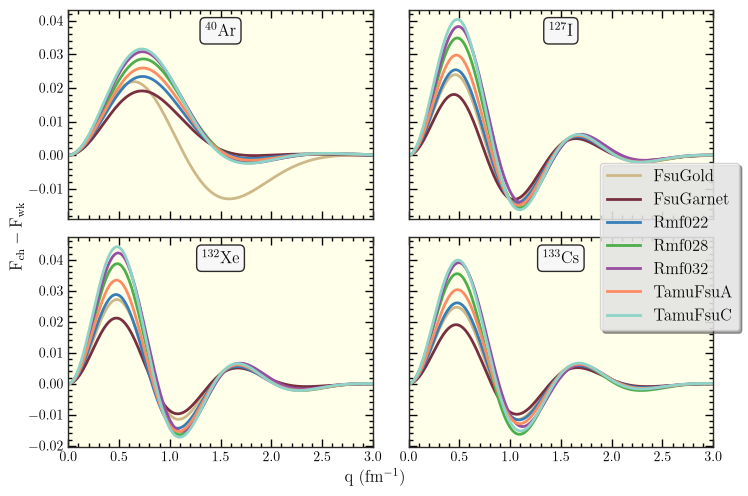

In [32]:
fig, ((ax1,ax2),(ax3,ax4))= plt.subplots(ncols=2, nrows=2, figsize=(7.3, 4.9), sharex=True, sharey='row')

ax1.plot(qax, ffargold[:,2]-ffargold[:,1], label='FsuGold')
ax1.plot(qax, ffargarnet[:,2]-ffargarnet[:,1], label='FsuGarnet')
ax1.plot(qax, ffarr022[:,2]-ffarr022[:,1], label='Rmf022')
ax1.plot(qax, ffarr028[:,2]-ffarr028[:,1], label='Rmf028')
ax1.plot(qax, ffarr032[:,2]-ffarr032[:,1], label='Rmf032')
ax1.plot(qax, ffarta[:,2]-ffarta[:,1], label='TamuFsuA')
ax1.plot(qax, ffartc[:,2]-ffartc[:,1], label='TamuFsuC')
ax1.text(0.5, 0.9, r'$^{40}\mathrm{Ar}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax1.transAxes )

ax1.set_xlim(0,3)

ax2.plot(qax, ffigold[:,2]-ffigold[:,1])
ax2.plot(qax, ffigarnet[:,2]-ffigarnet[:,1])
ax2.plot(qax, ffir022[:,2]-ffir022[:,1])
ax2.plot(qax, ffir028[:,2]-ffir028[:,1])
ax2.plot(qax, ffir032[:,2]-ffir032[:,1])
ax2.plot(qax, ffita[:,2]-ffita[:,1])
ax2.plot(qax, ffitc[:,2]-ffitc[:,1])
ax2.text(0.5, 0.9, r'$^{127}\mathrm{I}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax2.transAxes )

ax3.plot(qax, ffxegold[:,2]-ffxegold[:,1])
ax3.plot(qax, ffxegarnet[:,2]-ffxegarnet[:,1])
ax3.plot(qax, ffxer022[:,2]-ffxer022[:,1])
ax3.plot(qax, ffxer028[:,2]-ffxer028[:,1])
ax3.plot(qax, ffxer032[:,2]-ffxer032[:,1])
ax3.plot(qax, ffxeta[:,2]-ffxeta[:,1])
ax3.plot(qax, ffxetc[:,2]-ffxetc[:,1])
ax3.text(0.5, 0.9, r'$^{132}\mathrm{Xe}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax3.transAxes )

ax4.plot(qax, ffcsgold[:,2]-ffcsgold[:,1])
ax4.plot(qax, ffcsgarnet[:,2]-ffcsgarnet[:,1])
ax4.plot(qax, ffcsr022[:,2]-ffcsr022[:,1])
ax4.plot(qax, ffcsr028[:,2]-ffcsr028[:,1])
ax4.plot(qax, ffcsr032[:,2]-ffcsr032[:,1])
ax4.plot(qax, ffcsta[:,2]-ffcsta[:,1])
ax4.plot(qax, ffcstc[:,2]-ffcstc[:,1])
ax4.text(0.5, 0.9, r'$^{133}\mathrm{Cs}$', fontsize=12, ha='center',va='center',
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7'),  transform= ax4.transAxes )

fig.text(0, 0.5, r'$\mathrm{F_{ch}-F_{wk}}$', rotation='vertical', va='center', size=12)
fig.text(0.5, 0, r'$\mathrm{q\ (fm^{-1})}$', ha='center', size=12)
fig.legend(loc=5, bbox_to_anchor=(1.01,0.48))
fig.tight_layout()
fig.savefig('../figures/charge_weak_FF.pdf', bbox_inches='tight')

In [33]:
r=(4*np.pi/-20.4478)*simpson(rax1**4*argold[:,2], x=rax1)
r2=(4*np.pi/-20.4478)*simpson(rax1**6*argold[:,2], x=rax1)
r4=(4*np.pi/-20.4478)*simpson(rax1**8*argold[:,2], x=rax1)
print(r,r2,r4)

11.970290435760882 208.12682496185786 4854.460115072424


In [34]:
def fw(q):
    return 1 - (q**2.*r)/6 + (q**4.*r2)/120 #- (q**6.*r4)/5040 

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/3421368880.py:6: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(qax, np.abs(ffargold[:,1]), 'o', q, f(q))


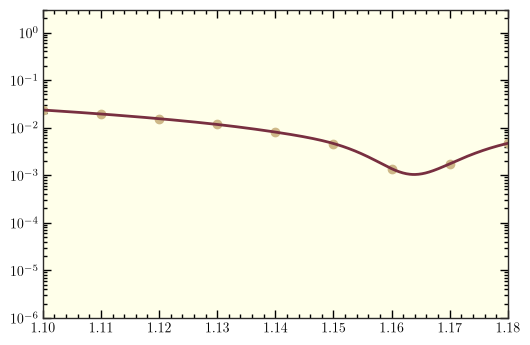

In [35]:
x=ffargold[:,0]
y=np.abs(ffargold[:,1])

f=interp1d(x,y,kind='cubic')
q=np.linspace(.001,15, 100000)
plt.plot(qax, np.abs(ffargold[:,1]), 'o', q, f(q))
plt.xlim(1.1,1.18)
plt.ylim(10**-6, 3)
plt.yscale('log')

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/2939067634.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(qax, fw(qax), 'o', qax, ffargold[:,1],'o')


(0.4, 1.0)

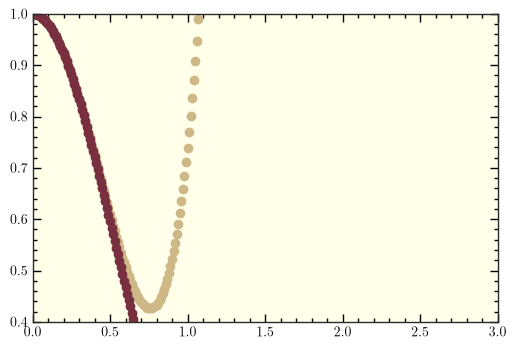

In [36]:
plt.plot(qax, fw(qax), 'o', qax, ffargold[:,1],'o')
plt.xlim(0,3)
plt.ylim(0.4,1)

In [37]:
ffpbgold = np.loadtxt('../results/densities/Pb208_fsugold_WeakFF.dat')
ffpbgarnet = np.loadtxt('../results/densities/Pb208_fsugarnet_WeakFF.dat')
ffpb022 = np.loadtxt('../results/densities/Pb208_rmf022_WeakFF.dat')
ffpb028 = np.loadtxt('../results/densities/Pb208_rmf028_WeakFF.dat')
ffpb032 = np.loadtxt('../results/densities/Pb208_rmf032_WeakFF.dat')
ffpbtfa = np.loadtxt('../results/densities/Pb208_tamufsua_WeakFF.dat')
ffpbtfc = np.loadtxt('../results/densities/Pb208_tamufsuc_WeakFF.dat')

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/263016218.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = fig.add_subplot(111)
/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/263016218.py:25: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  axins = zoomed_inset_axes(ax, 6, loc=1)


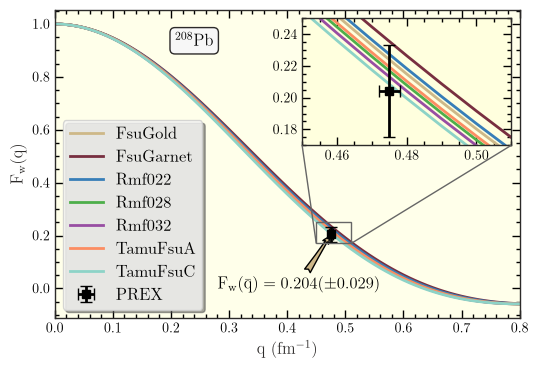

In [38]:
fig = plt.figure(figsize=(6.,4))
ax = fig.add_subplot(111)
ax.plot(ffpbgold[:,0], ffpbgold[:,1], label='FsuGold')
ax.plot(ffpbgarnet[:,0], ffpbgarnet[:,1], label='FsuGarnet')
ax.plot(ffpb022[:,0], ffpb022[:,1], label='Rmf022')
ax.plot(ffpb028[:,0], ffpb028[:,1], label='Rmf028')
ax.plot(ffpb032[:,0], ffpb032[:,1], label='Rmf032')
ax.plot(ffpbtfa[:,0], ffpbtfa[:,1], label='TamuFsuA')
ax.plot(ffpbtfc[:,0], ffpbtfc[:,1], label='TamuFsuC')
ax.errorbar(0.475, 0.204, xerr=[[.003],[.003]], yerr=[[0.029],[0.029]], color='k', fmt='s', zorder=10,label='PREX')
ax.annotate(r'$\mathrm{F_w(\bar{q})=0.204(\pm 0.029)}$', xy=(0.475,0.204), xytext=(0.28, 0),
            arrowprops=dict(arrowstyle='fancy'), fontsize=12,
            )
ax.text(0.3, 0.9, r'$^{208}\mathrm{Pb}$', size=12,
         ha="center", va="center", transform=ax.transAxes,
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7',
                   )
       )
ax.set_xlim(0, 0.8)
ax.set_xlabel(r'$\mathrm{q\ (fm^{-1})}$')
ax.set_ylabel(r'$\mathrm{F_w(q)}$')

axins = zoomed_inset_axes(ax, 6, loc=1)
axins.plot(ffpbgold[:,0], ffpbgold[:,1])
axins.plot(ffpbgarnet[:,0], ffpbgarnet[:,1])
axins.plot(ffpb022[:,0], ffpb022[:,1])
axins.plot(ffpb028[:,0], ffpb028[:,1])
axins.plot(ffpb032[:,0], ffpb032[:,1])
axins.plot(ffpbtfa[:,0], ffpbtfa[:,1])
axins.plot(ffpbtfc[:,0], ffpbtfc[:,1])
axins.errorbar(0.475, 0.204, xerr=[[.003],[.003]], yerr=[[0.029],[0.029]], color='k', fmt='s',zorder=10)
axins.set_xlim(0.45,0.51)
axins.set_ylim(0.17, 0.25)
#axins.set_yticklabels([])
#axins.set_xticklabels([])
mark_inset(ax, axins, loc1=3, loc2=4, fc="none", ec="0.4", zorder=10)

ax.legend(loc=3, fontsize=11.9)
fig.savefig('../figures/Pb208_WeakFF.pdf', bbox_inches='tight')
plt.show()

In [39]:
models=[ffpbgold,ffpbgarnet, ffpb022,ffpb028,ffpb032,ffpbtfa,ffpbtfc]

for mod in models:
    
    x = mod[:,0]
    y = mod[:,1]
    fwmod = interp1d(x,y,kind='cubic')
    diff= fwmod(0.475)-0.204
    print(fwmod(0.475), 'Diff:', diff )
    

0.22389730637496383 Diff: 0.01989730637496384
0.2354373859157036 Diff: 0.03143738591570361
0.22730556709016814 Diff: 0.02330556709016815
0.21681236777077173 Diff: 0.012812367770771743
0.21306996370656095 Diff: 0.009069963706560963
0.21933138345436928 Diff: 0.015331383454369296
0.20843709688091214 Diff: 0.00443709688091215


/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1949144155.py:2: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(ffpbgold[:,0], ffpbgold[:,1], label='FsuGold({:.3f})'.format(pbskins[0]))


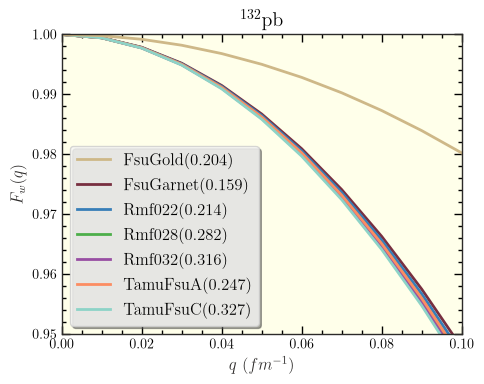

In [40]:
plt.figure(figsize=(5,4))
plt.plot(ffpbgold[:,0], ffpbgold[:,1], label='FsuGold({:.3f})'.format(pbskins[0]))
plt.plot(ffpbgarnet[:,0], ffpbgarnet[:,1], label='FsuGarnet({:.3f})'.format(pbskins[1]))
plt.plot(ffpb022[:,0], ffpb022[:,1], label='Rmf022({:.3f})'.format(pbskins[2]))
plt.plot(ffpb028[:,0], ffpb028[:,1], label='Rmf028({:.3f})'.format(pbskins[3]))
plt.plot(ffpb032[:,0], ffpb032[:,1], label='Rmf032({:.3f})'.format(pbskins[4]))
plt.plot(ffpbtfa[:,0], ffpbtfa[:,1], label='TamuFsuA({:.3f})'.format(pbskins[5]))
plt.plot(ffpbtfc[:,0], ffpbtfc[:,1], label='TamuFsuC({:.3f})'.format(pbskins[6]))

plt.plot(ffargold[:,0], ffargold[:,1])
plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.95,1)
plt.title(r'$^{132}\mathrm{pb}$')
plt.xlabel('$q\ (fm^{-1})$')
plt.ylabel('$F_{w}(q)$')
plt.tight_layout()
#plt.savefig('../figures/pb132_WeakFF.ffg',  bbox_inches='tight')
plt.show()

# CE$\nu$NS Cross Section

In [41]:
enu, goldsig =np.loadtxt('../results/cross_sections/Ar40_fsugold_cross.dat', unpack=True)
garnetsig = np.loadtxt('../results/cross_sections/Ar40_fsugarnet_cross.dat', usecols=1)
rmf022sig = np.loadtxt('../results/cross_sections/Ar40_rmf022_cross.dat', usecols=1)
rmf028sig = np.loadtxt('../results/cross_sections/Ar40_rmf028_cross.dat', usecols=1)
rmf032sig = np.loadtxt('../results/cross_sections/Ar40_rmf032_cross.dat', usecols=1)
tfasig = np.loadtxt('../results/cross_sections/Ar40_tamufsua_cross.dat', usecols=1)
tfcsig = np.loadtxt('../results/cross_sections/Ar40_tamufsuc_cross.dat', usecols=1)

In [42]:
c40en, ca40goldsig = np.loadtxt('../results/cross_sections/Ca40_fsugold_cross.dat', unpack=True)
c48en, ca48goldsig = np.loadtxt('../results/cross_sections/Ca48_fsugold_cross.dat', unpack=True)
aren, argoldsig = np.loadtxt('../results/cross_sections/Ar40_fsugold_cross.dat', unpack=True)
ien, igoldsig = np.loadtxt('../results/cross_sections/I127_fsugold_cross.dat', unpack=True)
xeen, xegoldsig = np.loadtxt('../results/cross_sections/Xe132_fsugold_cross.dat', unpack=True)
csen, csgoldsig = np.loadtxt('../results/cross_sections/Cs133_fsugold_cross.dat', unpack=True)
pben, pbgoldsig = np.loadtxt('../results/cross_sections/Pb208_fsugold_cross.dat', unpack=True)

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/3609070031.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(5,4))


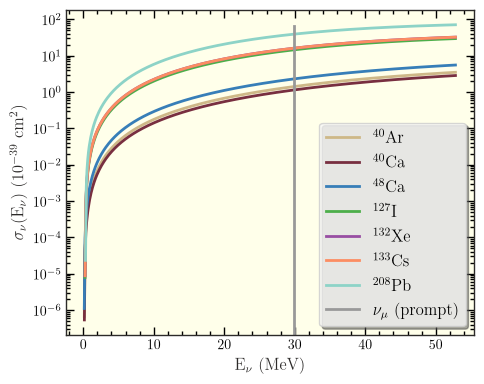

In [43]:
fig, ax = plt.subplots(figsize=(5,4))
ax.semilogy(aren, argoldsig*10**39, label=r'$\mathrm{^{40}Ar}$')
ax.semilogy(c48en, ca40goldsig*10**39, label=r'$\mathrm{^{40}Ca}$')
ax.semilogy(c40en, ca48goldsig*10**39, label=r'$\mathrm{^{48}Ca}$')
ax.semilogy(ien, igoldsig*10**39, label=r'$\mathrm{^{127}I}$')
ax.semilogy(xeen, xegoldsig*10**39, label=r'$\mathrm{^{132}Xe}$')
ax.semilogy(csen, csgoldsig*10**39, label=r'$\mathrm{^{133}Cs}$')
ax.semilogy(pben, pbgoldsig*10**39, label=r'$\mathrm{^{208}Pb}$')
ax.axvline(x=29.9, ymin=0, ymax=0.95, color='0.6', label=r'$\nu _{\mu}$ (prompt)')
ax.set_xlabel(r'$\mathrm{E_{\nu}\ (MeV)}$')
ax.set_ylabel(r'$\mathrm{\sigma_{\nu}(E_{\nu})\ (10^{-39}\ cm^{2})}$')
ax.legend(loc=4)

fig.tight_layout()
fig.savefig('../figures/nuclearcross.pdf', bbox_inches='tight')
plt.show()

In [44]:
itax, igolddsig = np.loadtxt('../results/cross_sections/I127_fsugold_diffcross.dat', unpack=True)
artax, argolddsig = np.loadtxt('../results/cross_sections/Ar40_fsugold_diffcross.dat', unpack=True)
c40tax, ca40golddsig = np.loadtxt('../results/cross_sections/Ca40_fsugold_diffcross.dat', unpack=True)
c48tax, ca48golddsig = np.loadtxt('../results/cross_sections/Ca48_fsugold_diffcross.dat', unpack=True)
xetax, xegolddsig = np.loadtxt('../results/cross_sections/Xe132_fsugold_diffcross.dat', unpack=True)
cstax, csgolddsig = np.loadtxt('../results/cross_sections/Cs133_fsugold_diffcross.dat', unpack=True)
pbtax, pbgolddsig = np.loadtxt('../results/cross_sections/Pb208_fsugold_diffcross.dat', unpack=True)

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/492427876.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.semilogy(c40tax,ca40golddsig*10**39, label=r'$^{b}\mathrm{}$')


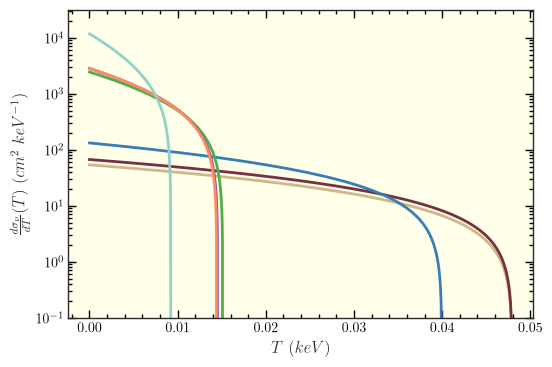

In [45]:
plt.semilogy(c40tax,ca40golddsig*10**39, label=r'$^{b}\mathrm{}$')
plt.semilogy(artax,argolddsig*10**39)
plt.semilogy(c48tax,ca48golddsig*10**39)
plt.semilogy(itax,igolddsig*10**39)
plt.semilogy(xetax,xegolddsig*10**39)
plt.semilogy(cstax,csgolddsig*10**39)
plt.semilogy(pbtax,pbgolddsig*10**39)
plt.xlabel('$T\ (keV$)')
plt.ylabel(r'$\frac{d\sigma _{\nu}}{dT}(T)\ (cm^{2}\ keV^{-1})$')
plt.ylim(10**(-1), 10**(4.5))
plt.show()

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/165221913.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(7.3,3.3))


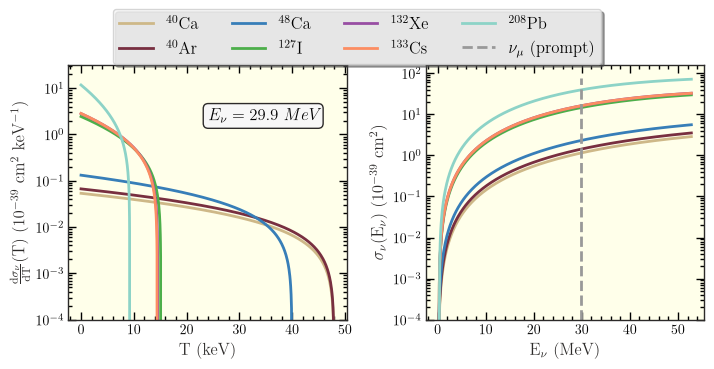

In [46]:
fig, ax = plt.subplots(ncols=2, nrows=1, figsize=(7.3,3.3))
ax[0].semilogy(c40tax*1000,ca40golddsig/1000*10**39)
ax[0].semilogy(artax*1000,argolddsig/1000*10**39)
ax[0].semilogy(c48tax*1000,ca48golddsig/1000*10**39)
ax[0].semilogy(itax*1000,igolddsig/1000*10**39)
ax[0].semilogy(xetax*1000,xegolddsig/1000*10**39)
ax[0].semilogy(cstax*1000,csgolddsig/1000*10**39)
ax[0].semilogy(pbtax*1000,pbgolddsig/1000*10**39)
ax[0].set_xlabel('T (keV)')
ax[0].set_ylabel(r'$\mathrm{\frac{d\sigma _{\nu}}{dT}(T)\ (10^{-39}\ cm^{2}\ keV^{-1})}$')
ax[0].set_ylim(10**(-4), 10**(1.5))
ax[0].text(0.7, 0.8, r'$E_{\nu}=29.9\ MeV$', size=12, va='center', ha='center', bbox=dict(boxstyle='round', ec='#2C2A29',
                                                       fc='#f7f7f7'), transform=ax[0].transAxes)

ax[1].semilogy(c40en, ca40goldsig*10**39, label=r'$\mathrm{^{40}Ca}$')
ax[1].semilogy(aren, argoldsig*10**39, label=r'$\mathrm{^{40}Ar}$')
ax[1].semilogy(c48en, ca48goldsig*10**39, label=r'$\mathrm{^{48}Ca}$')
ax[1].semilogy(ien, igoldsig*10**39, label=r'$\mathrm{^{127}I}$')
ax[1].semilogy(xeen, xegoldsig*10**39, label=r'$\mathrm{^{132}Xe}$')
ax[1].semilogy(csen, csgoldsig*10**39, label=r'$\mathrm{^{133}Cs}$')
ax[1].semilogy(pben, pbgoldsig*10**39, label=r'$\mathrm{^{208}Pb}$')
ax[1].axvline(x=29.9, ymin=0, ymax=0.95, color='0.6',ls='dashed', label=r'$\nu _{\mu}$ (prompt)')
ax[1].set_xlabel(r'$\mathrm{E_{\nu}\ (MeV)}$')
ax[1].set_ylabel(r'$\mathrm{\sigma_{\nu}(E_{\nu})\ (10^{-39}\ cm^{2})}$')
ax[1].set_ylim(10**-4,10**2.2)

fig.legend(loc=9, ncol=4, bbox_to_anchor=(0.5, 1.14))
fig.tight_layout()
fig.savefig('../figures/nuclearcross.pdf', bbox_inches='tight')

# Neutrino Spectra

In [47]:
mp=139.5701
mmu=105.6583
norm=0.08*1.76e23/(4*np.pi*20.)

In [48]:
def f_enu(E):
    return (96.0*E**2/mmu**4)*(mmu-(2*E))
def f_amu(E):
    return (16.0*E**2/mmu**4)*(3*mmu-4*E)

f_muy = 2*mp/(mp**2-mmu**2)
f_mux= (mp**2-mmu**2)/(2*mp)
print(f_mux)
sigtot = goldsig*(f_enu(enu) + f_amu(enu))

29.791969967493035


/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/3874309765.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots()


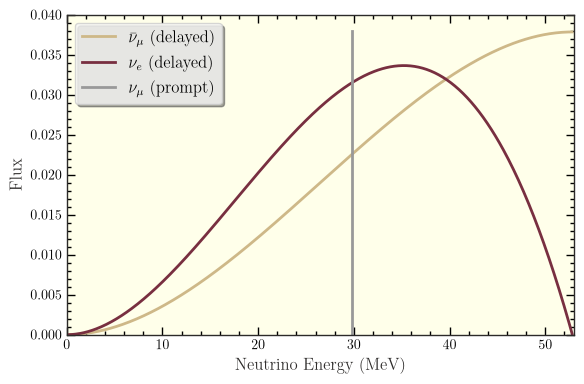

In [49]:
fig, ax = plt.subplots()
#ax.plot(enu, sigtot)
ax.plot(enu, f_amu(enu), label=r'$\bar{\nu}_{\mu}$ (delayed)')
ax.plot(enu, f_enu(enu), label=r'$\nu _e$ (delayed)')
ax.set_xlim(0,53)
ax.set_ylim(0,0.04)
ax.axvline(x=f_mux, ymin=0, ymax=0.95, color='0.6', label=r'$\nu _{\mu}$ (prompt)')
ax.legend()
ax.set_xlabel('Neutrino Energy (MeV)')
ax.set_ylabel('Flux')
fig.tight_layout()
fig.savefig('../figures/neutrino_flux.pdf', bbox_inches='tight')
plt.show()

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/2710413589.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots()


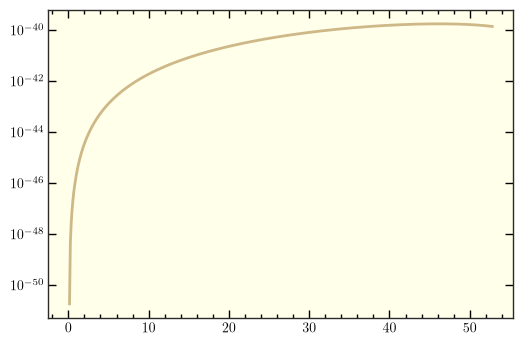

In [50]:
fig, ax = plt.subplots()
ax.semilogy(enu, sigtot)
plt.show()

In [51]:
simpson(sigtot, x=enu)

np.float64(3.749172577170097e-39)

In [52]:
def Fsf(q,a,c):
    x=q*c
    z=q*a
    return (3./(x*(x**2+(np.pi*z)**2)))*(np.pi*z/(np.sinh(np.pi*z)))*((np.pi*z/np.tanh(np.pi*z))*np.sin(x)-x*np.cos(x))

In [53]:
qax, ffpb=np.loadtxt('../results/densities/Pb208_fsugold_WeakFF.dat', usecols=(0,1), unpack=True)
F1=[Fsf(q,0.495,6.683) for q in qax]
F2=[Fsf(q,0.495,10) for q in qax]
F3=[Fsf(q,0.495,4) for q in qax]
F4=[Fsf(q,5,6.683) for q in qax]

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1671223464.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(qax, F1,qax,F2,'-.',qax,F3,'--',qax,F4,':', qax, ffpb)


(0.0, 0.8)

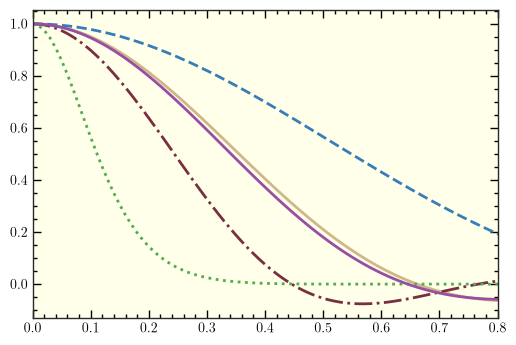

In [54]:
plt.plot(qax, F1,qax,F2,'-.',qax,F3,'--',qax,F4,':', qax, ffpb)
#plt.yscale('log')
plt.xlim(0,.8)
#plt.ylim(10**-6,10**0.3)

# Energy Spectra

In [55]:
ar40enn=np.loadtxt('../results/energies/Ar40_fsugold_energy.txt', usecols=(0,1))
argold40enp=np.loadtxt('../results/energies/Ar40_fsugold_energy.txt', usecols=(2,3))
argarnet40enp=np.loadtxt('../results/energies/Ar40_fsugarnet_energy.txt', usecols=(2,3))

In [56]:
print(ar40enn[:,1], argold40enp[:,1])

[-51.91291858 -37.71572396 -35.0833819  -22.0425197  -15.95288805
 -12.90136099  -7.04258243] [-48.60410017 -33.98255319 -31.35692161 -18.69254432 -12.54826212
   0.           0.        ]


In [57]:
argarnet40enp[:,1][:7]

array([-51.88560406, -34.9257129 , -29.75253041, -18.83720379,
       -12.54318958, -11.23975964,   0.        ])

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/1608549701.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax= plt.subplots(figsize=(5,6), sharey=True)


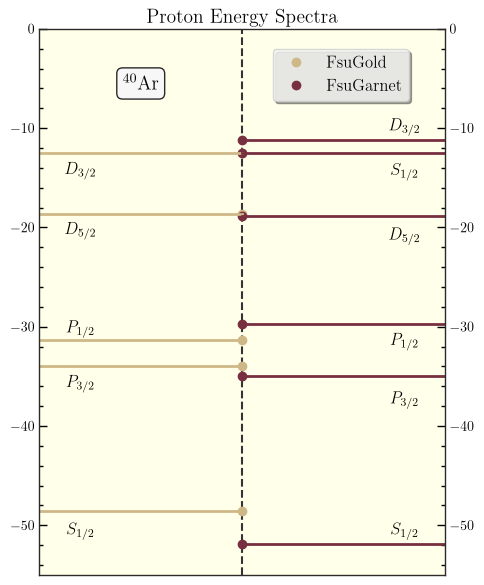

In [58]:
fig, ax= plt.subplots(figsize=(5,6), sharey=True)
ax.get_xaxis().set_visible(False)
ax.set_ylim(-55,0)
ax.tick_params(labeltop=False, labelright=True)
#neutrons
ax.plot([0.5,0.5,.5,.5,.5],argold40enp[:,1][:5], 'o',label='FsuGold')
ax.plot([0.5,0.5,.5,.5,.5,.5],argarnet40enp[:,1][:6], 'o',label='FsuGarnet')
for i in range(5):
    ax.axhline(y=argold40enp[:,1][i], xmin=0, xmax=0.5, c='#CEB888')
for i in range(6):
    ax.axhline(y=argarnet40enp[:,1][i], xmin=0.5, xmax=1, c='#782F40')
ax.axvline(x=0.5, c='.2', ls='--', lw=1.5, zorder=1)

ax.text(0.1, 0.08, r'$S_{1/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.1, 0.35, r'$P_{3/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.1, 0.45, r'$P_{1/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.1, 0.63, r'$D_{5/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.1, 0.74, r'$D_{3/2}$', size=12, va='center', ha='center', transform=ax.transAxes)

ax.text(0.9, 0.08, r'$S_{1/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.9, 0.32, r'$P_{3/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.9, 0.427, r'$P_{1/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.9, 0.62, r'$D_{5/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.9, 0.738, r'$S_{1/2}$', size=12, va='center', ha='center', transform=ax.transAxes)
ax.text(0.9, 0.82, r'$D_{3/2}$', size=12, va='center', ha='center', transform=ax.transAxes)

ax.text(0.25, 0.9, r'$^{40}\mathrm{Ar}$', size=14,
         ha="center", va="center", transform=ax.transAxes,
         bbox=dict(boxstyle="round",
                   ec='#2C2A29',
                   fc='#f7f7f7',
                   )
       )

ax.text(0.5, 1.02, 'Proton Energy Spectra', size=14, va='center', ha='center', transform=ax.transAxes)

fig.legend(loc=1, bbox_to_anchor=(.85,.92))
fig.tight_layout()

fig.savefig('../figures/arenspectra.pdf', bbox_inches='tight')

In [59]:
(139.57077**2-105.6583745**2)/(2*139.57077)

29.792440553314464

# Mirror Nuclei

In [60]:
x, ti50r12n, ti50r12p= np.loadtxt('../results/densities/Ti50_rmf012_nucleon_density.dat', usecols=(0,2,4), unpack=True)
ti50r22n, ti50r22p = np.loadtxt('../results/densities/Ti50_rmf022_nucleon_density.dat', usecols=(2,4), unpack=True)
ti50r28n, ti50r28p = np.loadtxt('../results/densities/Ti50_rmf028_nucleon_density.dat', usecols=(2,4), unpack=True)
ti50r32n, ti50r32p = np.loadtxt('../results/densities/Ti50_rmf032_nucleon_density.dat', usecols=(2,4), unpack=True)

/var/folders/2l/yv87nzw56wx9rzhnzfb_lg5m0000gn/T/ipykernel_35774/4186621231.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots()


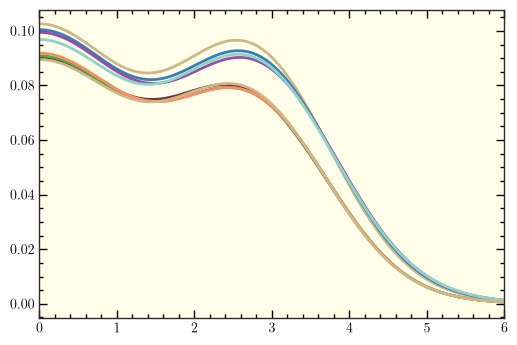

In [61]:
fig, ax = plt.subplots()
ax.set_xlim(0,6)
ax.plot(x, ti50r12n, x, ti50r12p, x, ti50r22n, x, ti50r22p, x, ti50r28n, x, ti50r28p, x, ti50r32n, x, ti50r32p)